In [1]:
import os
import random
import json
import logging

import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt

import sklearn.utils
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    Dense,
    Flatten,
    BatchNormalization,
    Dropout,
    DepthwiseConv2D,
)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Fix for TF/protobuf environment issues that can manifest as:
# AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
# Using the pure-Python protobuf implementation is a common Kaggle-safe workaround.
os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")

# Reproducibility (TF2-compatible)
SEED = 1372
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Working dir:", os.getcwd())



2026-01-10 20:12:15.535569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768075935.549822      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768075935.554154      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 20:12:15.571722: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow: 2.18.0
Working dir: /kaggle/working


In [2]:
# Resolve Kaggle input paths robustly.
# Prefer the competition folder if present, else fallback to generic ../input layout.
BASE_INPUT = "../input"
COMP_DIR = os.path.join(BASE_INPUT, "aerial-cactus-identification")

if os.path.exists(COMP_DIR):
    data_dir = COMP_DIR
else:
    data_dir = BASE_INPUT

train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
train_csv_path = os.path.join(data_dir, "train.csv")
sample_sub_path = os.path.join(data_dir, "sample_submission.csv")

print("data_dir:", data_dir)
print("train_dir:", train_dir, "exists:", os.path.exists(train_dir))
print("test_dir :", test_dir, "exists:", os.path.exists(test_dir))
print("train.csv:", train_csv_path, "exists:", os.path.exists(train_csv_path))
print(
    "sample_submission.csv:",
    sample_sub_path,
    "exists:",
    os.path.exists(sample_sub_path),
)

assert os.path.exists(train_dir), f"Train directory not found: {train_dir}"
assert os.path.exists(test_dir), f"Test directory not found: {test_dir}"
assert os.path.isfile(train_csv_path), f"Train CSV not found: {train_csv_path}"
assert os.path.isfile(
    sample_sub_path
), f"Sample submission not found: {sample_sub_path}"




data_dir: ../input/aerial-cactus-identification
train_dir: ../input/aerial-cactus-identification/train exists: True
test_dir : ../input/aerial-cactus-identification/test exists: True
train.csv: ../input/aerial-cactus-identification/train.csv exists: True
sample_submission.csv: ../input/aerial-cactus-identification/sample_submission.csv exists: True


In [3]:
# Kept for compatibility with original cells; not used by the current pipeline.
def resize_and_save(filename, input_dir, output_dir, size=32):
    """Resize the image contained in `filename` and save it to the `output_dir`"""
    from PIL import Image

    image = Image.open(os.path.join(input_dir, filename))
    image = image.resize((size, size))
    image.save(os.path.join(output_dir, filename))




In [4]:
class Params:
    """Class that loads hyperparameters from a json file."""

    def __init__(self, json_path):
        self.update(json_path)

    def save(self, json_path):
        """Saves parameters to json file"""
        with open(json_path, "w") as f:
            json.dump(self.__dict__, f, indent=4)

    def update(self, json_path):
        """Loads parameters from json file"""
        with open(json_path) as f:
            params = json.load(f)
            self.__dict__.update(params)

    @property
    def dict(self):
        """Gives dict-like access to Params instance by `params.dict['learning_rate']`"""
        return self.__dict__


def set_logger(log_path):
    """Sets the logger to log info in terminal and file `log_path`."""
    logger = logging.getLogger()
    logger.setLevel(logging.INFO)

    if not logger.handlers:
        file_handler = logging.FileHandler(log_path)
        file_handler.setFormatter(
            logging.Formatter("%(asctime)s:%(levelname)s: %(message)s")
        )
        logger.addHandler(file_handler)

        stream_handler = logging.StreamHandler()
        stream_handler.setFormatter(logging.Formatter("%(message)s"))
        logger.addHandler(stream_handler)


def save_dict_to_json(d, json_path):
    """Saves dict of floats in json file"""
    with open(json_path, "w") as f:
        d = {k: float(v) for k, v in d.items()}
        json.dump(d, f, indent=4)




In [5]:
# Load train labels and build full file paths
df = pd.read_csv(train_csv_path)
df = sklearn.utils.shuffle(df, random_state=SEED).reset_index(drop=True)

filenames = (train_dir + "/" + df["id"].astype(str)).values
labels = df["has_cactus"].astype(np.float32).values

print("Train samples:", len(filenames))
print("Example:", filenames[0], "label:", labels[0])



Train samples: 14175
Example: ../input/aerial-cactus-identification/train/b61963e2b36f23c178ae7ee637b59389.jpg label: 0.0


In [6]:
print("sample filename ", filenames[0])
print(
    "sample label (1 = exist) , (0 = doesnt exist any cactus) ",
    labels[0],
    type(labels[0]),
)




sample filename  ../input/aerial-cactus-identification/train/b61963e2b36f23c178ae7ee637b59389.jpg
sample label (1 = exist) , (0 = doesnt exist any cactus)  0.0 <class 'numpy.float32'>


In [7]:
# TF2-compatible parsing: tf.io.read_file and tf.image.resize
def _parse_function(filename, label, size):
    """Decode JPEG, convert to float [0,1], resize."""
    image_string = tf.io.read_file(filename)
    image_decoded = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image_decoded, tf.float32)
    resized_image = tf.image.resize(image, [size, size], method="bilinear")
    return resized_image, label




In [8]:
def train_preprocess(image, label, use_random_flip):
    """Training augmentation (kept identical intent)."""
    if use_random_flip:
        image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=32.0 / 255.0)
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label




In [9]:
def input_fn(is_training, filenames, labels, params):
    """Input function for the dataset."""
    num_samples = len(filenames)
    assert len(filenames) == len(labels), "Filenames and labels should have same length"

    parse_fn = lambda f, l: _parse_function(f, l, params.image_size)
    train_fn = lambda img, lab: train_preprocess(img, lab, params.use_random_flip)

    ds = tf.data.Dataset.from_tensor_slices((filenames, labels))
    if is_training:
        ds = ds.shuffle(num_samples, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(parse_fn, num_parallel_calls=params.num_parallel_calls)
        ds = ds.map(train_fn, num_parallel_calls=params.num_parallel_calls)
        ds = ds.batch(params.batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.map(parse_fn, num_parallel_calls=params.num_parallel_calls)
        ds = ds.batch(params.batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    return ds




In [10]:
# Keep params.json approach, but ensure JSON is valid (true/false, commas, etc.)
params_content = {
    "learning_rate": 1e-3,
    "batch_size": 32,
    "num_epochs": 10,
    "image_size": 32,
    "use_random_flip": True,
    "num_labels": 2,
    "num_parallel_calls": 4,
    "save_summary_steps": 1,
}
with open("params.json", "w") as f:
    json.dump(params_content, f, indent=2)

json_path = os.path.join("./", "params.json")
assert os.path.isfile(json_path), f"No json configuration file found at {json_path}"



In [11]:
params = Params(json_path)

# Fix split logic: original code trained on only 15% and validated on 85% (inverted).
split = int(len(filenames) * 0.15)
train_files, train_labels = filenames[split:], labels[split:]
valid_files, valid_labels = filenames[:split], labels[:split]

train_dataset = input_fn(True, train_files, train_labels, params)
valid_dataset = input_fn(False, valid_files, valid_labels, params)

print("Train size:", len(train_files), "Valid size:", len(valid_files))



2026-01-10 20:12:22.028514: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768075942.028923      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Train size: 12049 Valid size: 2126


(32, 32, 32, 3)  = batch-size & 32x32x3 image
1.0
1.0
1.0


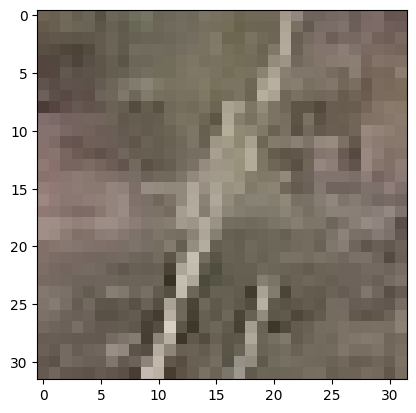

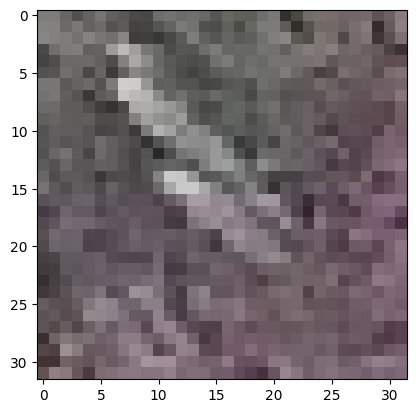

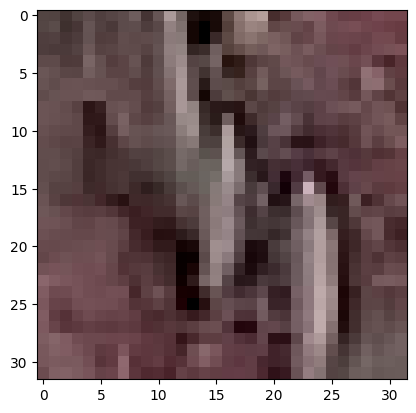

In [12]:
# TF2: directly iterate dataset to visualize a batch (no Session / iterators).
one_batch = next(iter(train_dataset.take(1)))
imgs, labs = one_batch
print(imgs.shape, " = batch-size & 32x32x3 image")
for i in range(3):
    plt.figure()
    print(float(labs[i].numpy()))
    plt.imshow(imgs[i].numpy())
    plt.grid(False)
plt.show()



In [13]:
model = Sequential()

model.add(Conv2D(3, kernel_size=3, activation="relu", input_shape=(32, 32, 3)))

model.add(Conv2D(filters=16, kernel_size=3, activation="relu"))
model.add(Conv2D(filters=16, kernel_size=3, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(DepthwiseConv2D(kernel_size=3, strides=1, padding="same", use_bias=True))
model.add(Conv2D(filters=32, kernel_size=1, activation="relu"))
model.add(Conv2D(filters=64, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(DepthwiseConv2D(kernel_size=3, strides=2, padding="same", use_bias=True))
model.add(Conv2D(filters=128, kernel_size=1, activation="relu"))
model.add(Conv2D(filters=256, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(DepthwiseConv2D(kernel_size=3, strides=1, padding="same", use_bias=True))
model.add(Conv2D(filters=256, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(filters=512, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(DepthwiseConv2D(kernel_size=3, strides=2, padding="same", use_bias=True))
model.add(Conv2D(filters=512, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(filters=512, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(DepthwiseConv2D(kernel_size=3, strides=1, padding="same", use_bias=True))
model.add(Conv2D(filters=1024, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(filters=1024, kernel_size=1, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(512, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="elu"))
model.add(Dense(1, activation="sigmoid"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Fix loss: tf.losses.log_loss is not available in TF2 Keras.
# Keep semantics: binary cross-entropy for sigmoid output.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=params.learning_rate),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 3)      │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 26, 26, 16)     │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 64)     │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 13, 13, 64)     │           640 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 256)    │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 13, 13, 256)    │         2,560 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 512)    │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 512)    │             

 Total params: 28,232,805 (107.70 MB)

 Trainable params: 28,222,917 (107.66 MB)

 Non-trainable params: 9,888 (38.62 KB)

In [15]:
file_path = "weights-aerial-cactus.keras"

# Fix monitor names for TF2 history keys: use 'val_accuracy' (not val_acc)
callbacks = [
    ModelCheckpoint(
        file_path, monitor="val_accuracy", verbose=1, save_best_only=True, mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1,
        mode="min",
        min_lr=0.00001,
    ),
    EarlyStopping(
        monitor="val_loss",
        min_delta=1e-10,
        patience=15,
        verbose=1,
        restore_best_weights=True,
    ),
]



In [16]:
# Fix steps math: use correct sizes for train/valid after split fix.
steps_per_epoch = int(np.ceil(len(train_files) / params.batch_size))
validation_steps = int(np.ceil(len(valid_files) / params.batch_size))

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    verbose=True,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
)



Epoch 1/20


I0000 00:00:1768075949.147687      61 service.cc:148] XLA service 0x7f9ab4003c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768075949.147727      61 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-10 20:12:29.274204: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768075949.963878      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


 21/377 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5858 - auc: 0.6119 - loss: 0.7450

I0000 00:00:1768075956.772006      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7499 - auc: 0.7796 - loss: 0.4814
Epoch 1: val_accuracy improved from -inf to 0.25118, saving model to weights-aerial-cactus.keras
377/377 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.7502 - auc: 0.7799 - loss: 0.4811 - val_accuracy: 0.2512 - val_auc: 0.5000 - val_loss: 4.6808 - learning_rate: 0.0010
Epoch 2/20
372/377 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9370 - auc: 0.9760 - loss: 0.1709
Epoch 2: val_accuracy improved from 0.25118 to 0.87865, saving model to weights-aerial-cactus.keras
377/377 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9372 - auc: 0.9762 - loss: 0.1704 - val_accuracy: 0.8786 - val_auc: 0.9824 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 3/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9673 - auc: 0.9914 - loss: 0.0942
Epoch 3: val_accuracy did not improve from 0.87865
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9673 - auc: 0.9914 - loss: 0.0941 - val_accuracy: 0.8683 -

In [17]:
# Load best checkpoint if it exists (training should have created it)
if os.path.exists(file_path):
    model.load_weights(file_path)
    print("Loaded weights from:", file_path)
else:
    print("Checkpoint not found, using current in-memory weights:", file_path)




Loaded weights from: weights-aerial-cactus.keras


In [18]:
def plot_training_curves(history):
    # TF2 uses 'accuracy'/'val_accuracy' keys; keep fallback for older names.
    h = history.history
    acc = h.get("accuracy", h.get("acc", []))
    val_acc = h.get("val_accuracy", h.get("val_acc", []))
    loss = h.get("loss", [])
    val_loss = h.get("val_loss", [])

    epochs = range(1, len(loss) + 1)

    plt.figure()
    plt.plot(epochs, loss, "r", label="Training loss")
    if len(val_loss):
        plt.plot(epochs, val_loss, "g", label="Validation loss")
    plt.title("Losses")
    plt.legend()
    plt.grid(True)

    if len(acc):
        plt.figure()
        plt.plot(epochs, acc, "r", label="Training acc")
        if len(val_acc):
            plt.plot(epochs, val_acc, "g", label="Validation acc")
        plt.title("Accuracies")
        plt.legend()
        plt.grid(True)

    if "auc" in h:
        plt.figure()
        plt.plot(epochs, h["auc"], "b", label="Training AUC")
        if "val_auc" in h:
            plt.plot(epochs, h["val_auc"], "k", label="Validation AUC")
        plt.title("AUC")
        plt.legend()
        plt.grid(True)

    plt.show()




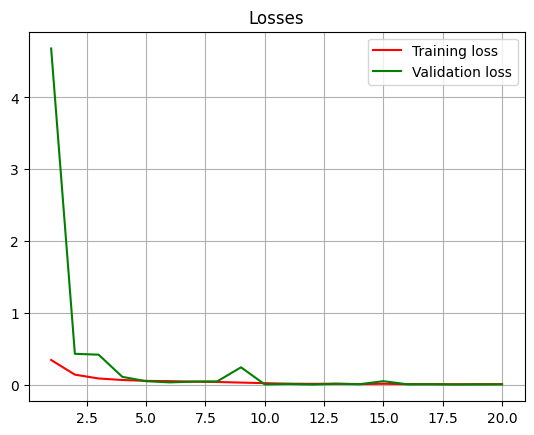

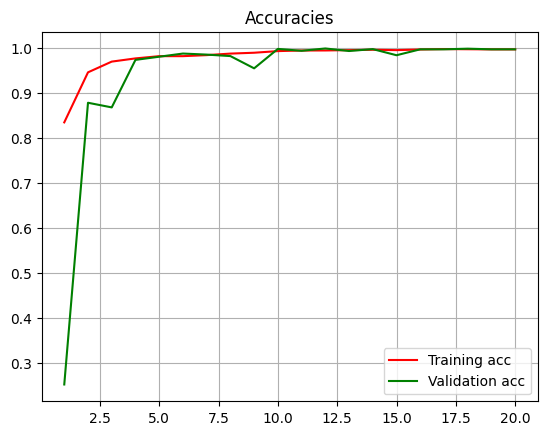

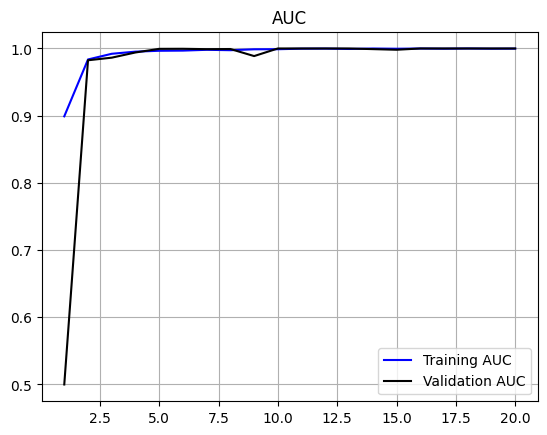

In [19]:
plot_training_curves(history)



In [20]:
# Inference: output probabilities directly (ROC AUC metric expects calibrated probabilities, no thresholding).
test_df = pd.read_csv(sample_sub_path)
images_test = test_df["id"].values

X_test = []
for img_id in tqdm(images_test, total=len(images_test)):
    img = cv.imread(os.path.join(test_dir, img_id))
    if img is None:
        raise FileNotFoundError(f"Could not read test image: {img_id} from {test_dir}")
    # cv2 reads BGR; training pipeline decodes RGB. For aerial cactus, this often doesn't break,
    # but to match training decode_jpeg (RGB), convert here.
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    X_test.append(img)

X_test = np.asarray(X_test, dtype=np.float32) / 255.0

y_test_pred = model.predict(X_test, batch_size=params.batch_size, verbose=0).reshape(-1)
test_df["has_cactus"] = y_test_pred.astype(np.float32)

# Ensure required format and filename with .csv suffix
submission_path = "submission.csv"
test_df.to_csv(submission_path, index=False)
print("Wrote submission to:", submission_path)
print(test_df.head())

100%|██████████| 3325/3325 [00:02<00:00, 1252.18it/s]


Wrote submission to: submission.csv
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.999993
1  134f04305c795d6d202502c2ce3578f3.jpg    0.999982
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999973
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.999985
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.999375
